In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
df = pd.read_csv("bangladesh_student_performance_updated.csv")

In [93]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
59,29/04/2018,M,18.0,Urban,GT3,Together,0,1,At_home,Teacher,Yes,Yes,109470.0,2,4.47,3.64
1551,29/04/2018,F,19.0,Urban,LE3,Together,3,2,Health,Farmer,No,No,96623.0,4,3.62,3.02
1545,29/04/2018,M,18.0,Urban,LE3,Apart,4,4,At_home,Services,No,No,115737.0,2,4.61,4.65
0,29/04/2018,M,18.0,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672.0,4,4.22,3.72
346,29/04/2018,F,19.0,Rural,GT3,Together,0,4,Services,Business,No,No,44262.0,2,3.25,2.83
454,29/04/2018,M,18.0,Rural,GT3,Together,0,0,At_home,Services,No,No,25160.0,1,3.38,2.89
1739,29/04/2018,M,17.0,Urban,GT3,Apart,2,2,Services,Farmer,No,No,95161.0,3,3.39,3.00
1022,29/04/2018,F,18.0,Rural,GT3,Together,1,3,Services,Teacher,No,No,50407.0,5,3.69,3.00
1741,29/04/2018,F,19.0,Rural,LE3,Together,2,3,Teacher,Teacher,No,No,57641.0,4,3.28,2.88
22,29/04/2018,M,17.0,Urban,LE3,Together,1,2,Teacher,Health,No,No,72031.0,5,4.93,4.42


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [95]:
df["time_friends"].unique()

array([4, 5, 3, 2, 1])

In [96]:
df["M_Edu"].unique()

array([3, 0, 2, 1, 4])

In [97]:
df['famsize'].unique()

array(['GT3', 'LE3'], dtype=object)

In [98]:
df.isnull().sum()

,0
date,0
gender,0
age,35
address,35
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,35
F_Job,0


In [99]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [100]:
df.duplicated().sum() #Duplicate find korar jonno
df.drop_duplicates(inplace=True) #Duplicate delete korar jonno

#EDA

Text(0.5, 0.98, 'Distrubution of Numerical feature')

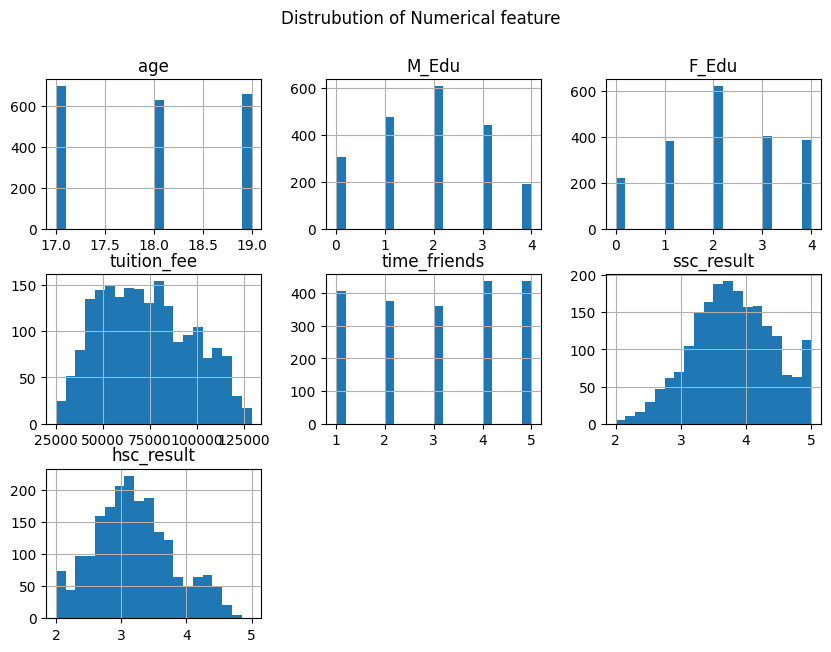

In [101]:
df.hist(bins=20, figsize=(10,7))


plt.suptitle("Distrubution of Numerical feature")

In [102]:
# Corelation Heatmap
Numerical_col = ['age', 'tuition_fee', 'ssc_result', 'hsc_result']

df[Numerical_col].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


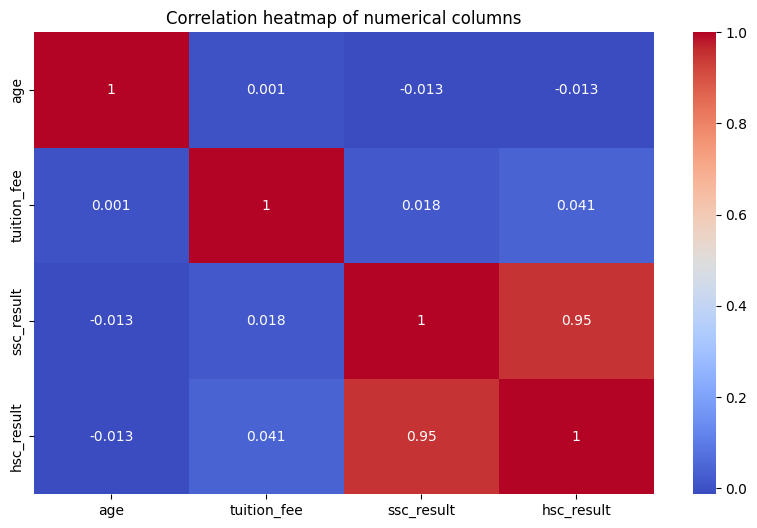

In [103]:
#Heat-Map

plt.figure(figsize=(10,6))

sns.heatmap(
    df[Numerical_col].corr(),
    annot = True,
    cmap = "coolwarm"
)

plt.title("Correlation heatmap of numerical columns")
plt.show()

<Axes: xlabel='ssc_result'>

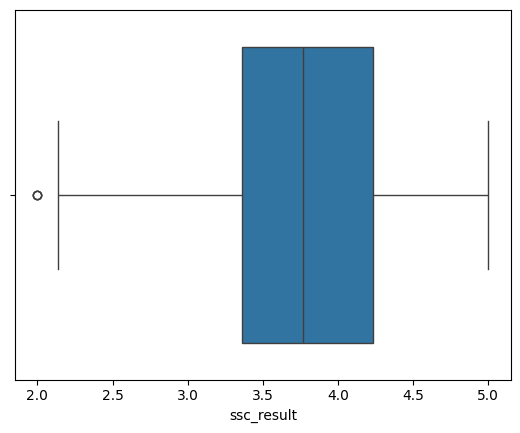

In [104]:
sns.boxplot(data = df, x = 'ssc_result')

#Pipeline in Sckit Learn

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline

In [106]:
#Nominal Data means No Order
#Ordinal Data means Has Order

nominal_cat = ['gender','address','famsize','Pstatus','relationship','smoker','F_Job','M_Job']
# ordina_cat = ['age','tuition_fee','ssc_result']

# M_edu_order = [0,1,2,3,4]
# F_edu_order = [0,1,2,3,4]
# Time_friend_order = [5,4,3,2,1]


Numerical_col = ['age', 'tuition_fee', 'ssc_result']

In [107]:
numerical_transformer_pipe = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'mean')),
        ('scaler', StandardScaler())
    ]
)
numerical_transformer_pipe

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [108]:
nominal_transformer_pipen = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoding', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
    ]
)
nominal_transformer_pipen

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoding',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [109]:
# ordinal_transformer_pipen = Pipeline(
#     steps = [
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('encoding', OrdinalEncoder(categories=[M_edu_order,F_edu_order,Time_friend_order])),
#         ('Scaling', MinMaxScaler())
#     ]
# )
# ordinal_transformer_pipen

In [110]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformer_pipe, Numerical_col),
        ('nominal', nominal_transformer_pipen, nominal_cat)
        # ('Ordinal_cate', ordinal_transformer_pipen, ordina_cat)
    ],
    remainder="passthrough" # Keep columns not specified in the transformers
)
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tuition_fee', 'ssc_result']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'address', 'famsize', 'Pstatus',
                                  'relationship', 'smoker', 'F_Job',
                                  'M_Job'])])

In [111]:
X = df.drop(['date', 'hsc_result'],axis=1)
y = df['hsc_result']

X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size=0.2, random_state=42)


In [112]:
X_train

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
746,M,19.0,Rural,LE3,Together,2,2,Other,Services,No,No,49318.0,3,4.95
1381,M,17.0,Urban,GT3,Together,0,1,Health,Farmer,No,Yes,88032.0,5,2.68
240,F,17.0,Urban,GT3,Together,4,3,Other,Services,No,No,116230.0,4,3.75
1646,M,18.0,Urban,LE3,Apart,2,1,Other,Business,No,No,79334.0,3,3.70
1460,M,18.0,Rural,GT3,Apart,4,3,At_home,Farmer,No,No,80248.0,2,3.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,F,18.0,Rural,GT3,Together,2,2,At_home,Health,No,No,50003.0,1,3.83
1294,F,19.0,Urban,LE3,Together,2,3,At_home,Farmer,Yes,No,110895.0,2,3.30
860,F,19.0,Rural,GT3,Together,0,2,Health,Farmer,No,No,51576.0,1,5.00
1459,F,18.0,Rural,GT3,Together,2,4,Other,Services,No,No,45830.0,1,4.42


In [113]:
y_train

,hsc_result
746,4.43
1381,2.07
240,3.11
1646,2.91
1460,3.66
...,...
1130,3.26
1294,2.72
860,4.57
1459,3.79


#Linear Regression

In [114]:
from sklearn.linear_model import LinearRegression,SGDRegressor

In [118]:
lr_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , LinearRegression())
    ]
)
lr_pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'F_Job', 'M_Job'])])),
                ('model', LinearRegression())])

In [121]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,17.0,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743.0,1,3.88
526,M,19.0,Rural,GT3,Together,4,3,At_home,Business,No,No,58678.0,5,4.36
393,F,18.0,Urban,GT3,Together,2,1,Services,Services,No,No,115832.0,3,4.47
1789,M,17.0,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781.0,1,4.43
433,M,19.0,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481.0,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17.0,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345.0,4,3.47
693,M,19.0,Urban,GT3,Together,1,2,Health,Business,No,No,85346.0,4,2.96
1494,F,18.0,Rural,LE3,Together,1,4,Teacher,Teacher,No,No,30638.0,1,3.76
921,M,NaN,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804.0,2,4.18


In [120]:
lr_pipe.predict(X_test)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

In [122]:
SGD_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , SGDRegressor())
    ]
)
SGD_pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'F_Job', 'M_Job'])])),
                ('model', SGDRegressor())])

In [125]:
SGD_pipe.predict(X_test)

array([3.21744213, 3.77957237, 3.84381841, 3.93838608, 3.84567588,
       3.35476252, 3.95043036, 2.50989085, 1.96786511, 3.29964441,
       3.68142625, 2.93430738, 3.24764404, 4.29417966, 3.06386285,
       2.63699888, 3.71893236, 3.39442512, 2.82644481, 2.94317949,
       2.82862589, 3.22809135, 2.96079401, 3.20186981, 1.91402007,
       2.49650192, 3.2233478 , 3.83432642, 3.04329133, 3.96637912,
       2.41301187, 3.95886235, 4.27639372, 2.58808216, 3.21779839,
       3.28889737, 2.77975251, 3.69036404, 2.50745409, 2.61606347,
       3.1082394 , 2.99775208, 3.74262385, 2.78168793, 2.14214256,
       3.09814174, 2.65833084, 2.60419106, 3.98210216, 3.23490893,
       3.0698517 , 3.47043937, 4.20246704, 3.62156971, 3.05732019,
       3.16404938, 3.31623278, 2.67918988, 3.8357449 , 2.60271836,
       3.03478081, 2.77305682, 2.48903823, 4.44460527, 2.58492788,
       3.22778129, 3.91527432, 2.68404207, 3.04416568, 3.19580252,
       3.03695906, 2.74791449, 2.6261532 , 3.66208479, 3.08179

In [126]:
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error

In [127]:
# Linear Regression
y_pred = lr_pipe.predict(X_test)

print(f"MSE : {round(mean_squared_error(y_test,y_pred),4)}")
print(f"r2_score : {round(r2_score(y_test,y_pred),4)}")
print(f"RMSE : {round(root_mean_squared_error(y_test,y_pred),4)}")
print(f"MAE : {round(mean_absolute_error(y_test,y_pred),4)}")

MSE : 0.0203
r2_score : 0.9459
RMSE : 0.1425
MAE : 0.1114


In [128]:
# SGD Regressor
y_pred = SGD_pipe.predict(X_test)

print(f"MSE : {round(mean_squared_error(y_test,y_pred),4)}")
print(f"r2_score : {round(r2_score(y_test,y_pred),4)}")
print(f"RMSE : {round(root_mean_squared_error(y_test,y_pred),4)}")
print(f"MAE : {round(mean_absolute_error(y_test,y_pred),4)}")

MSE : 0.0202
r2_score : 0.946
RMSE : 0.1423
MAE : 0.112
